# Permission Risk Scoring with Label Correction — Entertainment & Media

After computing the Borda+Garrett risk score and flagging apps where the score disagrees
with the given label, the flagged apps' labels are **flipped** (corrected to match what
their permission behavior suggests). All 4 classifiers are then trained and evaluated on
this corrected label set.

**Note on interpretation:** this evaluates classifiers against labels partly modified by
the same score-vs-label logic being tested. Report this as a label-correction / noisy-label
experiment, not as validation against independent ground truth.


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)

RANDOM_STATE = 42
FLAG_QUANTILE = 0.85
CATEGORY = "Entertainment & Media"
RESULTS_DIR = "results_Entertainment_and_Media"
os.makedirs(RESULTS_DIR, exist_ok=True)
pd.set_option("display.max_rows", 20)

In [2]:
df = pd.read_csv("Android_Permission.csv")
df.shape

(29999, 184)

## 1. All Categories in the Dataset

In [3]:
df["Category"].value_counts()

Category
Entertainment        2827
Travel & Local       2154
Books & Reference    1959
Arcade & Action      1959
Brain & Puzzle       1873
                     ... 
Sports Games          341
Photography           297
Racing                288
Medical               270
Weather               173
Name: count, Length: 30, dtype: int64

## 2. Group into 6 Broad Categories

In [4]:
BROAD_CATEGORY_MAP = {
    "Arcade & Action": "Games", "Brain & Puzzle": "Games", "Casual": "Games",
    "Cards & Casino": "Games", "Sports Games": "Games", "Racing": "Games",
    "Social": "Social & Communication", "Communication": "Social & Communication",
    "News & Magazines": "Social & Communication",
    "Tools": "Productivity & Tools", "Business": "Productivity & Tools",
    "Finance": "Productivity & Tools", "Productivity": "Productivity & Tools",
    "Libraries & Demo": "Productivity & Tools",
    "Entertainment": "Entertainment & Media", "Media & Video": "Entertainment & Media",
    "Music & Audio": "Entertainment & Media", "Comics": "Entertainment & Media",
    "Photography": "Entertainment & Media",
    "Education": "Education & Reference", "Books & Reference": "Education & Reference",
    "Travel & Local": "Lifestyle & Health", "Personalization": "Lifestyle & Health",
    "Lifestyle": "Lifestyle & Health", "Health & Fitness": "Lifestyle & Health",
    "Sports": "Lifestyle & Health", "Transportation": "Lifestyle & Health",
    "Shopping": "Lifestyle & Health", "Medical": "Lifestyle & Health",
    "Weather": "Lifestyle & Health",
}
df["BroadCategory"] = df["Category"].map(BROAD_CATEGORY_MAP)
df["BroadCategory"].value_counts()

BroadCategory
Lifestyle & Health        8064
Games                     7020
Entertainment & Media     5044
Productivity & Tools      4625
Education & Reference     3264
Social & Communication    1982
Name: count, dtype: int64

## 3. Preprocessing — Remove Duplicates

In [5]:
df = df.drop_duplicates().reset_index(drop=True)
df.shape

(27310, 185)

## 4. Map Real Permission Columns to the 12 Target Permissions

In [6]:
PERMISSION_COLUMN_MAP = {
    "Camera": ["Hardware controls : take pictures and videos (D)"],
    "Location": [
        "Your location : coarse (network-based) location (D)",
        "Your location : fine (GPS) location (D)",
        "Default : coarse (network-based) location (S)",
    ],
    "Contacts": [
        "Your personal information : read contact data (D)",
        "Your personal information : write contact data (D)",
        "Default : write contact data (S)",
        "Your accounts : contacts data in Google accounts (D)",
    ],
    "Microphone": ["Hardware controls : record audio (D)"],
    "Storage": [
        "Storage : modify/delete USB storage contents modify/delete SD card contents (D)",
        "Default : modify/delete USB storage contents modify/delete SD card contents (S)",
    ],
    "SMS": [
        "Services that cost you money : send SMS messages (D)",
        "Your messages : edit SMS or MMS (D)", "Your messages : read SMS or MMS (D)",
        "Your messages : receive SMS (D)", "Your messages : receive MMS (D)",
        "Your messages : send SMS-received broadcast (S)",
    ],
    "CallLogs": [],
    "Bluetooth": [
        "Network communication : create Bluetooth connections (D)",
        "System tools : bluetooth administration (D)",
    ],
    "Calendar": [
        "Your personal information : add or modify calendar events and send email to guests (D)",
        "Your personal information : read calendar events (D)",
    ],
    "PhoneState": [
        "Default : read phone state and identity (S)",
        "Phone calls : read phone state and identity (D)",
    ],
    "Internet": [
        "Default : full Internet access (S)",
        "Network communication : full Internet access (D)",
    ],
    "ReadPhoneNumbers": [],
}
PERMISSIONS = list(PERMISSION_COLUMN_MAP.keys())

perm_cols = {}
for target, sources in PERMISSION_COLUMN_MAP.items():
    valid = [c for c in sources if c in df.columns]
    perm_cols[target] = (df[valid].fillna(0).sum(axis=1) > 0).astype(int) if valid else pd.Series(0, index=df.index)
df = pd.concat([df, pd.DataFrame(perm_cols)], axis=1)

pd.Series({p: len(c) for p, c in PERMISSION_COLUMN_MAP.items()}, name="source_columns_used")

Camera              1
Location            3
Contacts            4
Microphone          1
Storage             2
SMS                 6
CallLogs            0
Bluetooth           2
Calendar            2
PhoneState          2
Internet            2
ReadPhoneNumbers    0
Name: source_columns_used, dtype: int64

## 5. Build Label and Proxy Risk Score

In [7]:
df["LabelEncoded"] = df["Class"].astype(int)
df["TrueLabel"] = df["LabelEncoded"].map({0: "Benign", 1: "Malicious"})

dpc = df["Dangerous permissions count"].astype(float).fillna(df["Dangerous permissions count"].median())
df["PrivacyRiskScore"] = (dpc - dpc.min()) / (dpc.max() - dpc.min() + 1e-9)

df[["TrueLabel", "PrivacyRiskScore"]].describe(include="all")

,TrueLabel,PrivacyRiskScore
count,27310,27310.000000
unique,2,NaN
top,Malicious,NaN
freq,18232,NaN
mean,NaN,0.100516
std,NaN,0.098926
min,NaN,0.000000
25%,NaN,0.033333
50%,NaN,0.066667
75%,NaN,0.133333


## 6. Select Category: Entertainment & Media

In [8]:
cat_df = df[df["BroadCategory"] == CATEGORY].reset_index(drop=True)
print(f"{CATEGORY}: {len(cat_df)} apps")
cat_df["TrueLabel"].value_counts(normalize=True)

Entertainment & Media: 4659 apps


TrueLabel
Malicious    0.667954
Benign       0.332046
Name: proportion, dtype: float64

## 7. Permission Rankings

In [9]:
N = len(PERMISSIONS)

def compute_rankings(data, permissions, label_col="LabelEncoded"):
    freq = data[permissions].sum()
    risk = pd.Series({p: data.loc[data[p] == 1, "PrivacyRiskScore"].mean() for p in permissions}).fillna(0)
    mal = pd.Series({p: data.loc[data[p] == 1, label_col].mean() for p in permissions}).fillna(0)
    return pd.DataFrame({
        "Permission": permissions,
        "Frequency": freq.values,
        "FrequencyRank": freq.rank(ascending=False, method="min").astype(int).values,
        "PrivacyRisk": risk.reindex(permissions).values,
        "PrivacyRank": risk.rank(ascending=False, method="min").astype(int).reindex(permissions).values,
        "MaliciousRate": mal.reindex(permissions).values,
        "MaliciousRank": mal.rank(ascending=False, method="min").astype(int).reindex(permissions).values,
    })

ranking_df = compute_rankings(cat_df, PERMISSIONS)
ranking_df

,Permission,Frequency,FrequencyRank,PrivacyRisk,PrivacyRank,MaliciousRate,MaliciousRank
0,Camera,328,5,0.177744,7,0.777439,2
1,Location,1005,4,0.192504,6,0.667662,3
2,Contacts,270,6,0.259506,1,0.540741,9
3,Microphone,262,7,0.195038,5,0.614504,6
4,Storage,2156,2,0.152551,9,0.601577,8
5,SMS,161,8,0.250932,3,0.614907,5
6,CallLogs,0,11,0.000000,11,0.000000,11
7,Bluetooth,52,10,0.255128,2,0.461538,10
8,Calendar,71,9,0.241315,4,0.887324,1
9,PhoneState,1777,3,0.170869,8,0.606640,7


## 8. Borda Score

In [10]:
def apply_borda(ranking_df, n):
    r = ranking_df.copy()
    r["BordaScore"] = (n - r["FrequencyRank"]) + (n - r["PrivacyRank"]) + (n - r["MaliciousRank"])
    r["BordaRank"] = r["BordaScore"].rank(ascending=False, method="min").astype(int)
    return r.sort_values("BordaRank")

borda_df = apply_borda(ranking_df, N)
borda_df[["Permission", "FrequencyRank", "PrivacyRank", "MaliciousRank", "BordaScore", "BordaRank"]]

,Permission,FrequencyRank,PrivacyRank,MaliciousRank,BordaScore,BordaRank
1,Location,4,6,3,23,1
0,Camera,5,7,2,22,2
8,Calendar,9,4,1,22,2
10,Internet,1,10,4,21,4
2,Contacts,6,1,9,20,5
5,SMS,8,3,5,20,5
3,Microphone,7,5,6,18,7
9,PhoneState,3,8,7,18,7
4,Storage,2,9,8,17,9
7,Bluetooth,10,2,10,14,10


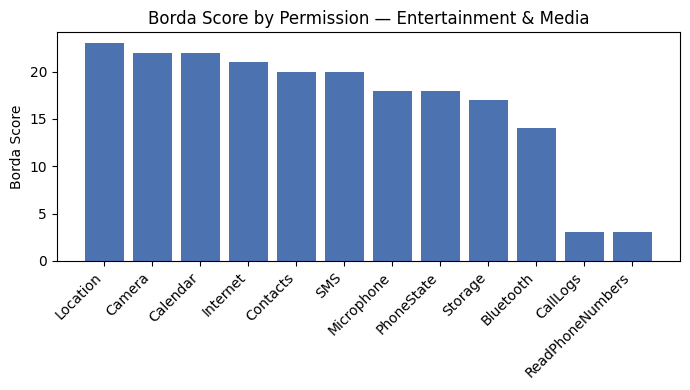

In [11]:
plt.figure(figsize=(7, 4))
plt.bar(borda_df["Permission"], borda_df["BordaScore"], color="#4C72B0")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Borda Score")
plt.title("Borda Score by Permission — Entertainment & Media")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "borda_score.png"), dpi=120)
plt.show()

## 9. Garrett Score

In [12]:
GARRETT_PCT = np.array([2,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,90,95,98])
GARRETT_SCORE = np.array([82,75,70,66,63,60,57,54,51,48,45,42,39,36,33,30,27,24,20,15,10])

def garrett_score(rank, n):
    pct = 100 * (rank - 0.5) / n
    return np.interp(pct, GARRETT_PCT, GARRETT_SCORE)

def apply_garrett(ranking_df, n):
    r = ranking_df.copy()
    r["GarrettTotal"] = (
        r["FrequencyRank"].apply(lambda x: garrett_score(x, n))
        + r["PrivacyRank"].apply(lambda x: garrett_score(x, n))
        + r["MaliciousRank"].apply(lambda x: garrett_score(x, n))
    )
    r["GarrettRank"] = r["GarrettTotal"].rank(ascending=False, method="min").astype(int)
    return r.sort_values("GarrettRank")

garrett_df = apply_garrett(ranking_df, N)
garrett_df[["Permission", "FrequencyRank", "PrivacyRank", "MaliciousRank", "GarrettTotal", "GarrettRank"]]

,Permission,FrequencyRank,PrivacyRank,MaliciousRank,GarrettTotal,GarrettRank
1,Location,4,6,3,167.500000,1
8,Calendar,9,4,1,166.944444,2
0,Camera,5,7,2,163.000000,3
10,Internet,1,10,4,161.944444,4
2,Contacts,6,1,9,156.944444,5
5,SMS,8,3,5,152.500000,6
3,Microphone,7,5,6,142.500000,7
9,PhoneState,3,8,7,142.500000,7
4,Storage,2,9,8,138.000000,9
7,Bluetooth,10,2,10,123.000000,10


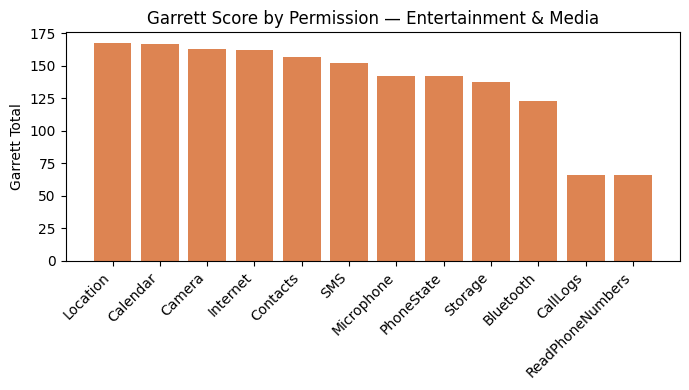

In [13]:
plt.figure(figsize=(7, 4))
plt.bar(garrett_df["Permission"], garrett_df["GarrettTotal"], color="#DD8452")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Garrett Total")
plt.title("Garrett Score by Permission — Entertainment & Media")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "garrett_score.png"), dpi=120)
plt.show()

## 10. Normalized Risk Weights

In [14]:
def normalize_weights(garrett_df):
    w = garrett_df.set_index("Permission")["GarrettTotal"]
    return (w / w.sum()).sort_values(ascending=False)

weights = normalize_weights(garrett_df)
weights

Permission
Location            0.101710
Calendar            0.101373
Camera              0.098978
Internet            0.098337
Contacts            0.095301
SMS                 0.092602
Microphone          0.086530
PhoneState          0.086530
Storage             0.083797
Bluetooth           0.074689
CallLogs            0.040077
ReadPhoneNumbers    0.040077
Name: GarrettTotal, dtype: float64

## 11. Baseline Privacy Score

In [15]:
def baseline_score(data, permissions, weights):
    return sum(data[p] * weights[p] for p in permissions)

cat_df["BaselinePrivacyScore"] = baseline_score(cat_df, PERMISSIONS, weights)
cat_df[["App", "BaselinePrivacyScore", "TrueLabel"]].head()

,App,BaselinePrivacyScore,TrueLabel
0,Kuma Clock,0.000000,Malicious
1,MX Video Player CODEC (ARMv7),0.000000,Benign
2,LiveWallpaper Clock 010,0.000000,Malicious
3,J-Roc Soundboard,0.083797,Malicious
4,iMediaShare,0.268664,Benign


## 12. Disagreement Rule — Flag Apps

In [16]:
def flag_disagreements(data, scores, quantile=0.85):
    disagreement = (scores - data["LabelEncoded"]).abs()
    threshold = disagreement.quantile(quantile)
    flagged_mask = disagreement >= threshold
    return flagged_mask, disagreement

flagged_mask, disagreement = flag_disagreements(cat_df, cat_df["BaselinePrivacyScore"], FLAG_QUANTILE)
cat_df["Disagreement"] = disagreement
cat_df["Flagged"] = flagged_mask

print(f"Flagged: {flagged_mask.sum()} apps ({flagged_mask.mean()*100:.1f}% of category)")
cat_df.loc[flagged_mask, ["App", "Package", "BaselinePrivacyScore", "TrueLabel", "Disagreement"]].sort_values("Disagreement", ascending=False).head(15)

Flagged: 1351 apps (29.0% of category)


,App,Package,BaselinePrivacyScore,TrueLabel,Disagreement
21,More Cowbell!,com.bbm.android.cowbell,0.0,Malicious,1.0
4653,Ghost Trap (No Ads),com.bustin.ghosttrapdonate,0.0,Malicious,1.0
0,Kuma Clock,com.livedoor.android.kuma_clock,0.0,Malicious,1.0
2,LiveWallpaper Clock 010,net.liveroid.android.clock010,0.0,Malicious,1.0
27,LiveWallpaper095-liveroid,net.liveroid.livewallpaper095,0.0,Malicious,1.0
4652,MW2 Guide,com.mw2guide,0.0,Malicious,1.0
4587,TSSweetCaramel FlipFont,com.monotype.android.font.tssweetcaramel,0.0,Malicious,1.0
4582,WWE SmackDo vs Raw 2010 Cheats,com.llm.m080,0.0,Malicious,1.0
4578,Here's To You,com.futurewisetechnologies.mobile.herestoyou,0.0,Malicious,1.0
4575,VPlayer Unlocker,me.abitno.vplayer.unlocker,0.0,Malicious,1.0


In [17]:
cat_df.loc[flagged_mask, ["App", "Package", "Category", "BaselinePrivacyScore", "TrueLabel", "Disagreement"]]\
    .sort_values("Disagreement", ascending=False)\
    .to_csv(os.path.join(RESULTS_DIR, "flagged_apps.csv"), index=False)
weights.to_csv(os.path.join(RESULTS_DIR, "risk_weights.csv"))
print("Saved: flagged_apps.csv, risk_weights.csv")

Saved: flagged_apps.csv, risk_weights.csv


## 13. Flip Labels of Flagged Apps

Flagged apps' labels are corrected to the opposite of their original label — the direction
the disagreement rule suggests their actual behavior points to.

In [18]:
cat_df["CorrectedLabel"] = cat_df["LabelEncoded"]
cat_df.loc[flagged_mask, "CorrectedLabel"] = 1 - cat_df.loc[flagged_mask, "LabelEncoded"]

n_flipped = flagged_mask.sum()
print(f"Labels flipped: {n_flipped} out of {len(cat_df)} ({n_flipped/len(cat_df)*100:.1f}%)")
print()
print("Label distribution — original vs corrected:")
pd.DataFrame({
    "Original": cat_df["LabelEncoded"].value_counts().sort_index(),
    "Corrected": cat_df["CorrectedLabel"].value_counts().sort_index(),
})

Labels flipped: 1351 out of 4659 (29.0%)

Label distribution — original vs corrected:


,Original,Corrected
0,1547,2898
1,3112,1761


## 14. Feature Preparation (target = CorrectedLabel)

In [19]:
EXTRA_FEATURES = ["Rating", "Number of ratings", "Price", "Dangerous permissions count", "Safe permissions count"]
FEATURE_COLS = PERMISSIONS + EXTRA_FEATURES

for c in EXTRA_FEATURES:
    cat_df[c] = pd.to_numeric(cat_df[c], errors="coerce").fillna(0)

X = cat_df[FEATURE_COLS].values
y = cat_df["CorrectedLabel"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (3727, 17), Test: (932, 17)


In [20]:
def evaluate(y_true, scores, threshold=0.5):
    preds = (scores >= threshold).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, preds),
        "Precision": precision_score(y_true, preds, zero_division=0),
        "Recall": recall_score(y_true, preds, zero_division=0),
        "F1": f1_score(y_true, preds, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, scores) if pd.Series(y_true).nunique() > 1 else float("nan"),
    }

## 15. Decision Tree Classifier

In [21]:
dt_clf = DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=RANDOM_STATE)
dt_clf.fit(X_train, y_train)
dt_pred = dt_clf.predict(X_test)
dt_proba = dt_clf.predict_proba(X_test)[:, 1]

dt_metrics = evaluate(y_test, dt_proba)
pd.Series(dt_metrics, name="Decision Tree")

Accuracy     0.766094
Precision    0.634538
Recall       0.897727
F1           0.743529
ROC-AUC      0.867540
Name: Decision Tree, dtype: float64

In [22]:
confusion_matrix(y_test, dt_pred)

array([[398, 182],
       [ 36, 316]])

## 16. Random Forest Classifier

In [23]:
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced", random_state=RANDOM_STATE)
rf_clf.fit(X_train, y_train)
rf_pred = rf_clf.predict(X_test)
rf_proba = rf_clf.predict_proba(X_test)[:, 1]

rf_metrics = evaluate(y_test, rf_proba)
pd.Series(rf_metrics, name="Random Forest")

Accuracy     0.769313
Precision    0.629002
Recall       0.948864
F1           0.756512
ROC-AUC      0.892437
Name: Random Forest, dtype: float64

In [24]:
confusion_matrix(y_test, rf_pred)

array([[383, 197],
       [ 18, 334]])

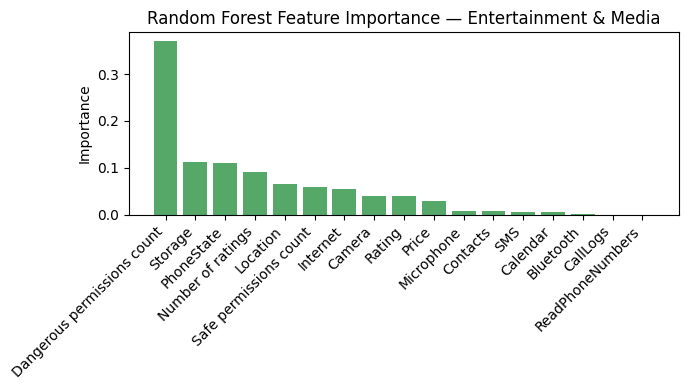

In [25]:
importances = pd.Series(rf_clf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
plt.figure(figsize=(7, 4))
plt.bar(importances.index, importances.values, color="#55A868")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance — Entertainment & Media")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "rf_feature_importance.png"), dpi=120)
plt.show()

## 17. AdaBoost Classifier

In [26]:
ada_clf = AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE)
ada_clf.fit(X_train, y_train)
ada_pred = ada_clf.predict(X_test)
ada_proba = ada_clf.predict_proba(X_test)[:, 1]

ada_metrics = evaluate(y_test, ada_proba)
pd.Series(ada_metrics, name="AdaBoost")

Accuracy     0.771459
Precision    0.682415
Recall       0.738636
F1           0.709413
ROC-AUC      0.868628
Name: AdaBoost, dtype: float64

In [27]:
confusion_matrix(y_test, ada_pred)

array([[459, 121],
       [ 92, 260]])

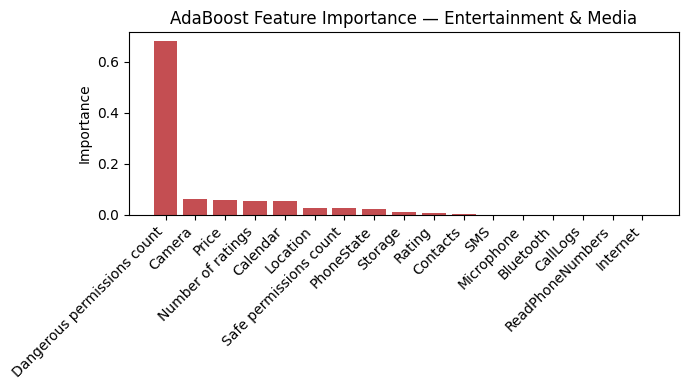

In [28]:
ada_importances = pd.Series(ada_clf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
plt.figure(figsize=(7, 4))
plt.bar(ada_importances.index, ada_importances.values, color="#C44E52")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Importance")
plt.title("AdaBoost Feature Importance — Entertainment & Media")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "adaboost_feature_importance.png"), dpi=120)
plt.show()

## 18. SVM Classifier

In [29]:
svm_clf = SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE)
svm_clf.fit(X_train_scaled, y_train)
svm_pred = svm_clf.predict(X_test_scaled)
svm_proba = svm_clf.predict_proba(X_test_scaled)[:, 1]

svm_metrics = evaluate(y_test, svm_proba)
pd.Series(svm_metrics, name="SVM")

Accuracy     0.766094
Precision    0.632937
Recall       0.906250
F1           0.745327
ROC-AUC      0.851029
Name: SVM, dtype: float64

In [30]:
confusion_matrix(y_test, svm_pred)

array([[375, 205],
       [ 13, 339]])

## 19. ROC Curve — All Classifiers

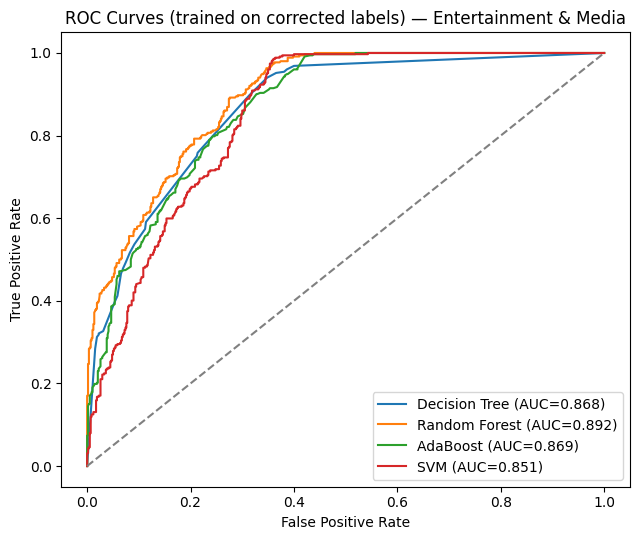

In [31]:
plt.figure(figsize=(6.5, 5.5))
for name, proba in [("Decision Tree", dt_proba), ("Random Forest", rf_proba),
                     ("AdaBoost", ada_proba), ("SVM", svm_proba)]:
    fpr_c, tpr_c, _ = roc_curve(y_test, proba)
    auc_c = roc_auc_score(y_test, proba)
    plt.plot(fpr_c, tpr_c, label=f"{name} (AUC={auc_c:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (trained on corrected labels) — Entertainment & Media")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "roc_all_classifiers.png"), dpi=120)
plt.show()

## 20. Classifier Comparison (post label-correction)

In [32]:
comparison = pd.DataFrame({
    "Decision Tree": dt_metrics,
    "Random Forest": rf_metrics,
    "AdaBoost": ada_metrics,
    "SVM": svm_metrics,
}).round(4)
comparison

,Decision Tree,Random Forest,AdaBoost,SVM
Accuracy,0.7661,0.7693,0.7715,0.7661
Precision,0.6345,0.6290,0.6824,0.6329
Recall,0.8977,0.9489,0.7386,0.9062
F1,0.7435,0.7565,0.7094,0.7453
ROC-AUC,0.8675,0.8924,0.8686,0.8510


In [33]:
comparison.to_csv(os.path.join(RESULTS_DIR, "classifier_comparison_post_correction.csv"))
print(f"All results saved to: {RESULTS_DIR}/")
print(os.listdir(RESULTS_DIR))

All results saved to: results_Entertainment_and_Media/
['adaboost_feature_importance.png', 'borda_score.png', 'classifier_comparison_post_correction.csv', 'flagged_apps.csv', 'garrett_score.png', 'rf_feature_importance.png', 'risk_weights.csv', 'roc_all_classifiers.png']
